In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# MONTER LE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# lire le fichier
DATASET_PATH = ('/content/drive/MyDrive/Projet_Riz/Rice')



In [ ]:
# vérification des classes de riz
import os

classes = os.listdir(DATASET_PATH)
print("Classes de riz :", classes)


Classes de riz : ['Arborio', 'Karacadag', 'Jasmine', 'Ipsala', 'Basmati']


In [ ]:
# vérification du nombre d'image par classe
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    print(cls, ":", len(os.listdir(cls_path)), "images")


Arborio : 100 images
Karacadag : 100 images
Jasmine : 100 images
Ipsala : 100 images
Basmati : 100 images


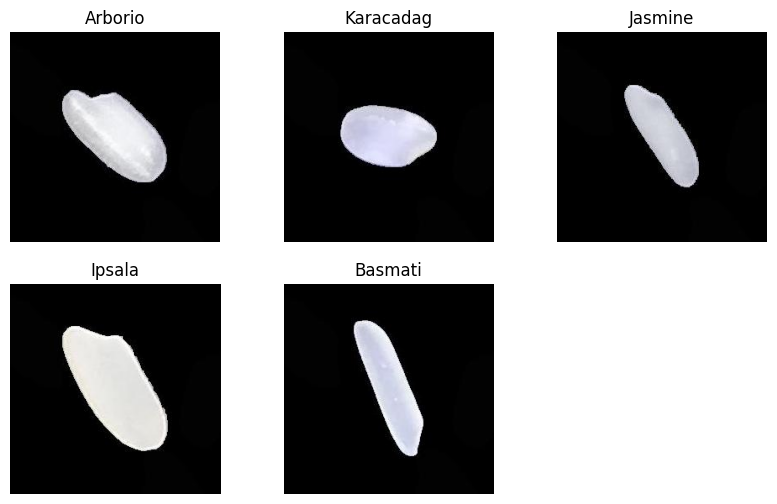

In [ ]:
# visualisation de quelque images
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(10,6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()


In [ ]:
# prétraitement définition des paramètres
IMG_SIZE = (224, 224)   # taille standard MobileNetV2
BATCH_SIZE = 16
SEED = 42


In [ ]:
# générateur de prétraitement
from tensorflow.keras.preprocessing.image import ImageDataGenerator

preprocess_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalisation
    validation_split=0.2   # 80 % / 20 %
)


In [ ]:
# générateur train
train_generator = preprocess_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)


Found 400 images belonging to 5 classes.


In [ ]:
# générateur validation et test
temp_generator = preprocess_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=SEED
)
# vérification de l'encodage des classes
print(train_generator.class_indices)


Found 100 images belonging to 5 classes.
{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


In [ ]:
# vérification de la forme des données
images, labels = next(train_generator)
print("Shape des images :", images.shape)
print("Shape des labels :", labels.shape)
print("Valeurs min/max des pixels :", images.min(), images.max())


Shape des images : (16, 224, 224, 3)
Shape des labels : (16, 5)
Valeurs min/max des pixels : 0.0 1.0


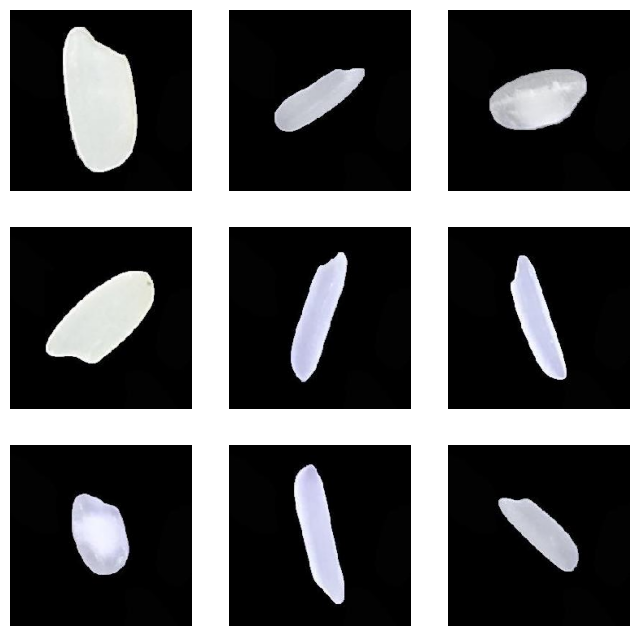

In [ ]:
# visualisation des images après prétraitement
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()


In [ ]:
# séparation des 20% en (10% validation et 10% test)

# chargement du générateur temporaire en mémoire
import numpy as np

X_temp, y_temp = [], []

for i in range(len(temp_generator)):
    x_batch, y_batch = temp_generator[i]
    X_temp.append(x_batch)
    y_temp.append(y_batch)

X_temp = np.concatenate(X_temp)
y_temp = np.concatenate(y_temp)

print("Temp images :", X_temp.shape)
print("Temp labels :", y_temp.shape)


Temp images : (100, 224, 224, 3)
Temp labels : (100, 5)


In [ ]:
# Séparer Validation et Test
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Validation :", X_val.shape)
print("Test :", X_test.shape)


Validation : (50, 224, 224, 3)
Test : (50, 224, 224, 3)


In [ ]:
# vérification de la distribution des classes
import numpy as np

print("Répartition Validation :", np.sum(y_val, axis=0))
print("Répartition Test :", np.sum(y_test, axis=0))


Répartition Validation : [10. 10. 10. 10. 10.]
Répartition Test : [10. 10. 10. 10. 10.]


In [ ]:
# data augmentation sur le train

# définition de la data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalisation
    rotation_range=15,        # Rotation légère
    width_shift_range=0.1,    # Décalage horizontal
    height_shift_range=0.1,   # Décalage vertical
    zoom_range=0.1,           # Zoom léger
    horizontal_flip=True,     # Flip horizontal
    fill_mode='nearest'       # Remplissage des pixels
)

# recréation du générateur train avec data augmentation
train_aug_generator = train_aug_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)



Found 500 images belonging to 5 classes.


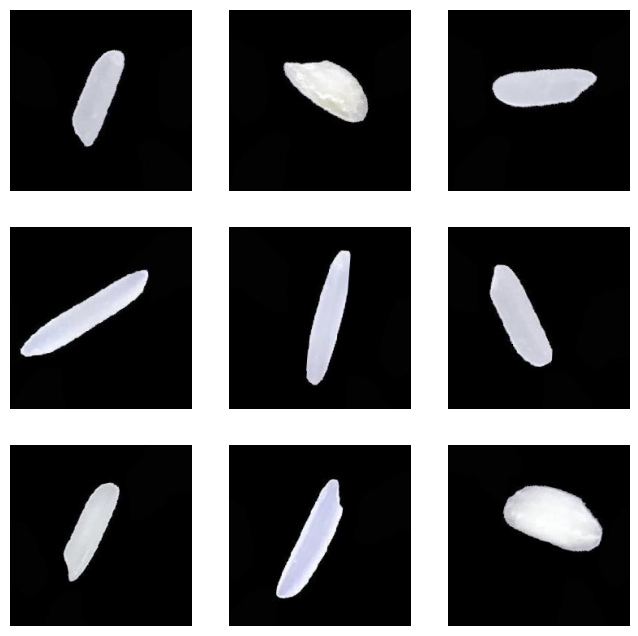

Pixels min/max : 0.0 1.0
Shape images : (16, 224, 224, 3)
Shape labels : (16, 5)


In [ ]:
# visualisation du data augmentation
import matplotlib.pyplot as plt

images, labels = next(train_aug_generator)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

 # vérification finale
print("Pixels min/max :", images.min(), images.max())
print("Shape images :", images.shape)
print("Shape labels :", labels.shape)


In [ ]:
# MobileNetV2 (Transfer Learning)

# import et prétraitement
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
# chargement du mobilenetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # on enlève la tête ImageNet
    weights='imagenet'
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# géle des couches de la base
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
# Ajout de  la tête de classification
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(5, activation='softmax')(x)  # 5 types de riz

model = models.Model(inputs=base_model.input, outputs=outputs)


In [ ]:
# compilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# résumé du modèle
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# callbaks(anti-overfitting)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_rice_model.keras',
    monitor='val_loss',
    save_best_only=True
)


In [ ]:
# entrainement du modèle
history = model.fit(
    train_aug_generator,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.2520 - loss: 1.9115 - val_accuracy: 0.7000 - val_loss: 1.1092
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 839ms/step - accuracy: 0.5453 - loss: 1.1377 - val_accuracy: 0.7800 - val_loss: 0.8489
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 827ms/step - accuracy: 0.7374 - loss: 0.7916 - val_accuracy: 0.9000 - val_loss: 0.6458
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 834ms/step - accuracy: 0.7895 - loss: 0.6673 - val_accuracy: 0.9200 - val_loss: 0.5281
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 855ms/step - accuracy: 0.8562 - loss: 0.5230 - val_accuracy: 0.9400 - val_loss: 0.4440
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 829ms/step - accuracy: 0.8503 - loss: 0.5079 - val_accuracy: 0.9400 - val_loss: 0.3827
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 804ms/step - accuracy: 0.8818 - loss: 0.3987 - val_accuracy: 0.9600 - val_loss: 0.3444
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 789ms/step - accuracy: 0.8908 - loss: 0.3619 - val_accura

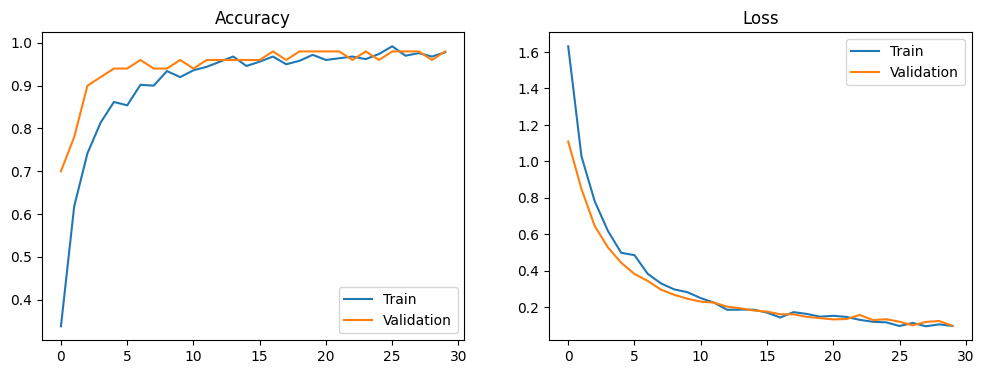

In [ ]:
# courbe d'apprentissage

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()


In [ ]:
# fine-tuning

# On dégèle uniquement les dernières couches de MobileNetV2
FINE_TUNE_AT = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True


In [ ]:
# recompilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# entrainement fine-tuning

history_fine = model.fit(
    train_aug_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8666 - loss: 0.3985 - val_accuracy: 0.9800 - val_loss: 0.1357
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9525 - loss: 0.2314 - val_accuracy: 0.9800 - val_loss: 0.1361
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9486 - loss: 0.2026 - val_accuracy: 0.9800 - val_loss: 0.1345
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9402 - loss: 0.1976 - val_accuracy: 0.9800 - val_loss: 0.1251
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9557 - loss: 0.1596 - val_accuracy: 0.9800 - val_loss: 0.1302
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9608 - loss: 0.1299 - val_accuracy: 0.9600 - val_loss: 0.1270
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9613 - loss: 0.1668 - val_accuracy: 0.9800 - val_loss: 0.1210
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9635 - loss: 0.1404 - val_accuracy: 0.9600 - val_loss:

In [ ]:
# évaluation détaillée
#Prédictions sur le jeu de TEST
import numpy as np

# Prédictions (probabilités)
y_pred_prob = model.predict(X_test)

# Classe prédite (argmax)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classe réelle
y_true = np.argmax(y_test, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


In [ ]:
# Precision, Recall, F1-score
from sklearn.metrics import classification_report

class_names = list(train_aug_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

     Arborio       1.00      1.00      1.00        10
     Basmati       1.00      1.00      1.00        10
      Ipsala       1.00      1.00      1.00        10
     Jasmine       1.00      1.00      1.00        10
   Karacadag       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



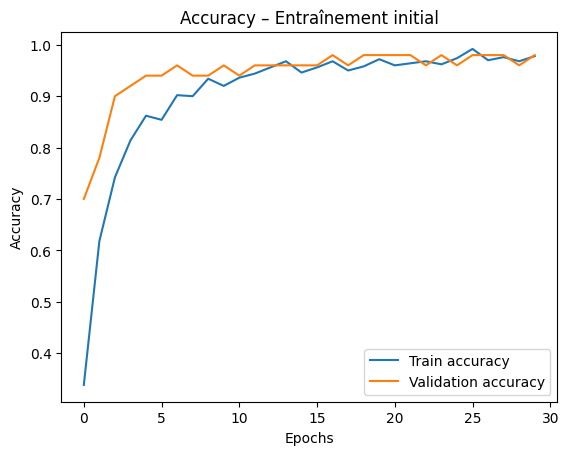

In [ ]:
# Courbe Accuracy (Train vs Validation)
plt.figure()
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy – Entraînement initial')
plt.legend()
plt.show()


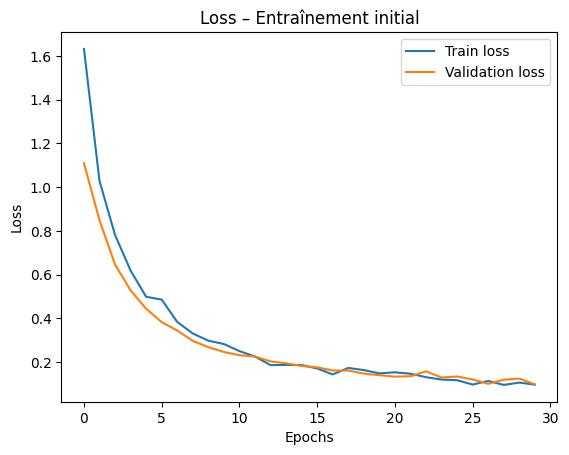

In [ ]:
# Courbe Loss (Train vs Validation)
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss – Entraînement initial')
plt.legend()
plt.show()


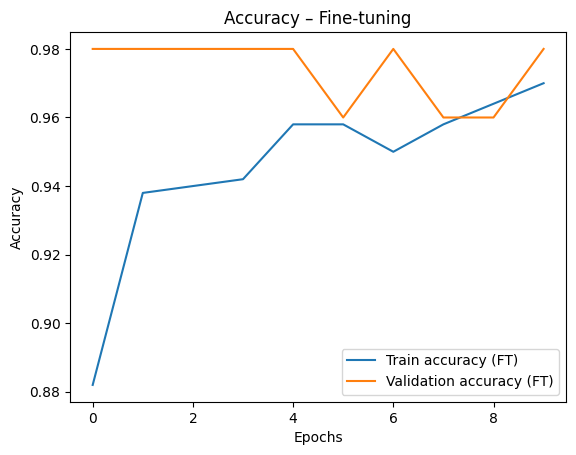

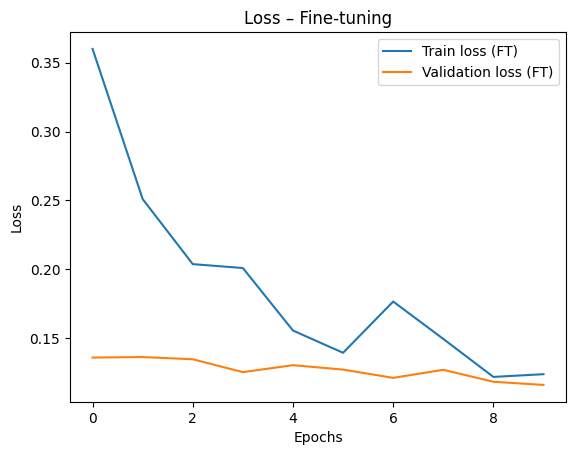

In [ ]:
# Courbes Accuracy & Loss après Fine-Tuning

#accuracy
plt.figure()
plt.plot(history_fine.history['accuracy'], label='Train accuracy (FT)')
plt.plot(history_fine.history['val_accuracy'], label='Validation accuracy (FT)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy – Fine-tuning')
plt.legend()
plt.show()

# loss
plt.figure()
plt.plot(history_fine.history['loss'], label='Train loss (FT)')
plt.plot(history_fine.history['val_loss'], label='Validation loss (FT)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss – Fine-tuning')
plt.legend()
plt.show()


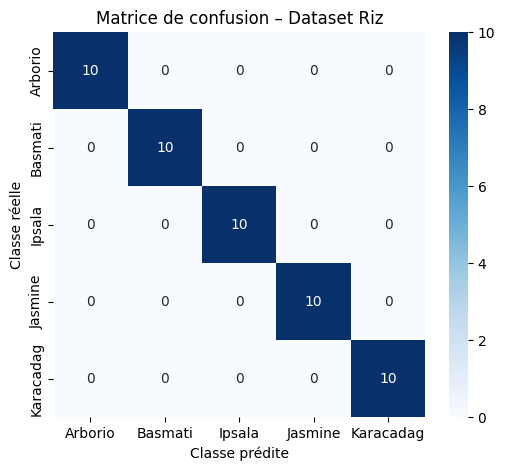

In [ ]:
# matrice de confusion

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.title('Matrice de confusion – Dataset Riz')
plt.show()


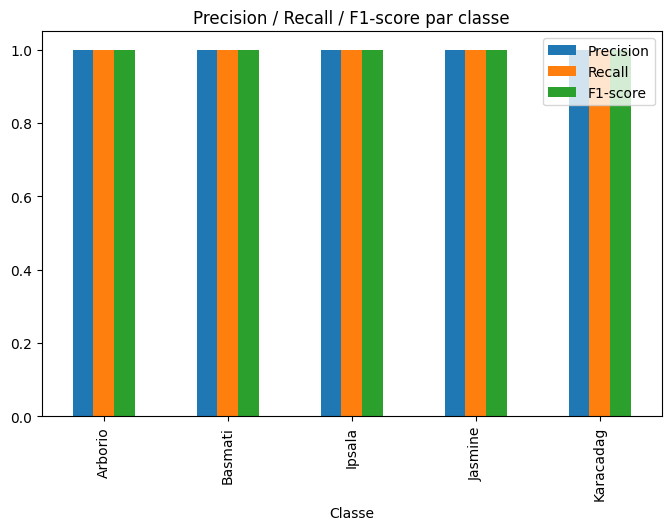

In [ ]:
# Courbe Precision / Recall / F1-score par classe
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

df_metrics = pd.DataFrame({
    'Classe': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

df_metrics.plot(x='Classe', kind='bar', figsize=(8,5))
plt.title('Precision / Recall / F1-score par classe')
plt.ylim(0, 1.05)
plt.show()


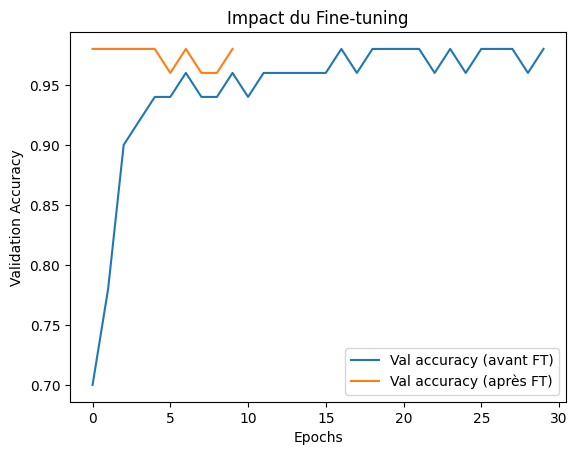

In [ ]:
# Courbe Comparaison Avant vs Après Fine-Tuning
plt.figure()
plt.plot(history.history['val_accuracy'], label='Val accuracy (avant FT)')
plt.plot(history_fine.history['val_accuracy'], label='Val accuracy (après FT)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Impact du Fine-tuning')
plt.legend()
plt.show()


In [ ]:
# sauvegarde du model
model.save("rice_mobilenetv2_final.keras")


In [ ]:
!cp rice_mobilenetv2_final.keras /content/drive/MyDrive/


In [ ]:
import os

os.listdir("/content/drive/MyDrive/")


['Projet_Riz',
 'Snapchat-388795520 (1).jpg',
 'Snapchat-388795520.jpg',
 'projet groupe 5.pptx',
 'TP2.rar',
 "projet de développement web'1 (1).rar",
 "projet de développement web'1.rar",
 'PharmacyMS-Laravel.zip',
 'CrudMongo (1).rar',
 'CrudMongo.rar',
 'PFC.docx',
 'IMG-20190811-WA0097.jpg',
 'PFC (2) (1).docx',
 'PFC (2).docx',
 'PFC (2).docm',
 'PFC (1).docm',
 'PFC (2).pdf',
 'mon projet.pdf',
 'CV de Sophie FALL.pdf',
 'Adobe Scan 19 déc. 2024.pdf',
 "Documents d'analyse et de conception",
 "Rapport d'audit de SICOFT",
 'CV de Sophie FALL_letrre_motivation.pdf',
 "Projet de digitalisation sur mesure pour l'ANIPL-28-04-25 (1).gdoc",
 "Projet de digitalisation sur mesure pour l'ANIPL-28-04-25.gdoc",
 'Documents_de_travail_ANIPL',
 'ORACLE',
 'srv-laboracle',
 'LISTE DES PARTICIPANTS POUR LE HACKATON AMRE1.pdf',
 'FALL_SOPHIE_MedQR.pptx',
 'RAPPORT DSI.gdoc',
 "Etat d'avancement des différents projets & plan d'action pour les mois à venir.gdoc",
 'fouilles de données salini